<a href="https://colab.research.google.com/github/rdityaza/Data-Analytics/blob/main/Tugas_06_18223086_Raditya_Zaki_Athaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Analitik Data: Multi-class Classification dengan Naive Bayes dan kNN

Notebook ini disiapkan untuk membantu mahasiswa mengerjakan tugas klasifikasi multiclass menggunakan **Naive Bayes** dan **k-Nearest Neighbors (kNN)** menggunakan dataset yang disediakan.

## Tujuan pembelajaran
1. Mengimplementasikan pipeline klasifikasi multiclass.
2. Membandingkan performa **Gaussian Naive Bayes** dan **kNN**.
3. Melakukan **hyperparameter tuning** pada kNN.
4. Menafsirkan hasil melalui metrik evaluasi dan visualisasi aktual vs prediksi.
5. Menyusun kesimpulan berbasis bukti berupa luaran model, visualisasi, dan kinerja model.



In [ ]:
# =========================
# 1. Import library
# =========================
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [ ]:
# =========================
# 2. Load dataset
# =========================
def find_dataset(filename="digital_service_customer_multiclass.csv"):
    candidates = [
        Path.cwd() / filename,
        Path.cwd() / "data" / filename,
        Path("/mnt/data") / filename
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Dataset {filename} tidak ditemukan. Letakkan file pada folder notebook, folder data/, atau /mnt/data/."
    )

data_path = find_dataset()
df = pd.read_csv(data_path)
print("Dataset loaded from:", data_path)
print("Shape:", df.shape)
df.head()


Dataset loaded from: /content/digital_service_customer_multiclass.csv
Shape: (1000, 18)


,customer_id,age,monthly_usage_hours,avg_session_duration,num_logins_per_week,feature_adoption_score,support_tickets,monthly_spending,payment_consistency_score,tenure_months,engagement_score,last_campaign_response,device_diversity,referral_count,churn_risk_score,preferred_plan,region,segment_class
0,C0522,32.2,46.2,18.0,12.9,89.8,4,459.03,76.5,20.5,62.1,Opened,3,1,28.5,Family,West,Premium
1,C0738,36.3,37.3,13.5,7.6,48.2,3,560.54,96.4,23.7,71.2,No Response,2,2,39.4,Business,Central,Premium
2,C0741,32.2,42.6,11.3,6.4,71.3,1,375.86,78.3,27.4,70.3,Converted,1,1,53.1,Standard,East,Premium
3,C0661,33.4,37.9,17.9,5.0,47.4,1,490.26,67.0,34.9,60.3,Clicked,3,2,43.0,Pro,Central,Premium
4,C0412,34.4,33.9,15.3,7.3,32.7,2,233.42,86.2,9.7,53.6,Clicked,2,0,62.8,Pro,Central,Growth


## TUGAS MAHASISWA 1
Jelaskan secara singkat konteks masalah klasifikasi pada dataset ini dan arti dari target `segment_class`.


###**Penjelasan Konteks Masalah**
Masalah klasifikasi ini bertujuan untuk memprediksi perilaku dan segmentasi (customer segmentation) pengguna sebuah layanan digital berbasis metrik riwayat demografi, aktivitas sesi, engagement, hingga riwayat transaksi (monthly spending). Model ini dapat membantu tim bisnis untuk menargetkan strategi kampanye dengan lebih efisien dan terarah.

Arti dari target segment_class merupakan variabel dependen berbentuk kategorik (klasifikasi multiclass) yang merepresentasikan nilai hierarkis pelanggan. Target ini terbagi ke dalam empat kelas, mulai dari skala kebutuhan terendah hingga tertingi: Basic, Growth, Premium, dan Enterprise.

In [ ]:
# =========================
# 3. Eksplorasi awal
# =========================
print(df.info())
print("\nJumlah missing value per kolom:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDistribusi kelas target:")
display(df["segment_class"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                1000 non-null   object 
 1   age                        1000 non-null   float64
 2   monthly_usage_hours        1000 non-null   float64
 3   avg_session_duration       1000 non-null   float64
 4   num_logins_per_week        1000 non-null   float64
 5   feature_adoption_score     980 non-null    float64
 6   support_tickets            1000 non-null   int64  
 7   monthly_spending           1000 non-null   float64
 8   payment_consistency_score  985 non-null    float64
 9   tenure_months              1000 non-null   float64
 10  engagement_score           1000 non-null   float64
 11  last_campaign_response     985 non-null    object 
 12  device_diversity           1000 non-null   int64  
 13  referral_count             1000 non-null   int64 

,0
feature_adoption_score,20
payment_consistency_score,15
last_campaign_response,15
preferred_plan,10
age,0
customer_id,0
num_logins_per_week,0
support_tickets,0
avg_session_duration,0
monthly_usage_hours,0



Distribusi kelas target:


,count
segment_class,
Enterprise,257
Premium,253
Growth,245
Basic,245


Dataset terdiri dari 1000 baris dengan 18 fitur. Terdapat indikasi missing values pada fitur numerik (skor adopsi dan konsistensi) serta fitur kategorik (last campaign dan preferred plan). Hal ini mengonfirmasi perlunya tahap imputasi data menggunakan median/modus agar tidak terjadi bias pada model.

In [ ]:
# Statistik deskriptif fitur numerik
df.describe(include=[np.number]).T


,count,mean,std,min,25%,50%,75%,max
age,1000.0,32.087000,8.324511,18.0,26.10,32.050,37.925,58.90
monthly_usage_hours,1000.0,37.460600,15.413277,3.0,26.10,37.600,48.600,87.50
avg_session_duration,1000.0,13.828800,6.041529,3.0,9.20,14.000,18.000,29.60
num_logins_per_week,1000.0,7.277000,3.406005,1.0,4.80,7.100,9.700,19.40
feature_adoption_score,980.0,58.962857,20.360967,5.0,45.00,59.950,73.625,100.00
support_tickets,1000.0,2.031000,1.431114,0.0,1.00,2.000,3.000,7.00
monthly_spending,1000.0,398.948820,215.628134,40.0,235.37,386.825,558.640,940.91
payment_consistency_score,985.0,74.505990,15.988527,30.0,63.60,75.400,86.100,100.00
tenure_months,1000.0,22.563500,12.244239,1.0,13.10,22.200,31.125,57.50
engagement_score,1000.0,60.445700,20.299134,10.0,45.70,61.250,75.750,99.00


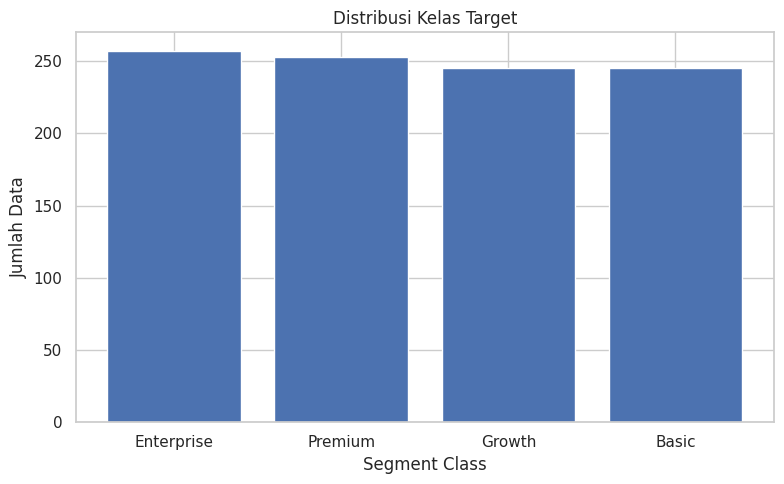

In [ ]:
# Visualisasi distribusi kelas target
class_counts = df["segment_class"].value_counts()
plt.figure(figsize=(8,5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Distribusi Kelas Target")
plt.xlabel("Segment Class")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()


Distribusi kelas target (segment_class) sangat seimbang di angka ~250 per kelas. Ini adalah kondisi ideal untuk pemodelan klasifikasi karena model tidak akan cenderung 'memihak' pada kelas mayoritas, sehingga metrik Accuracy menjadi sangat relevan digunakan.

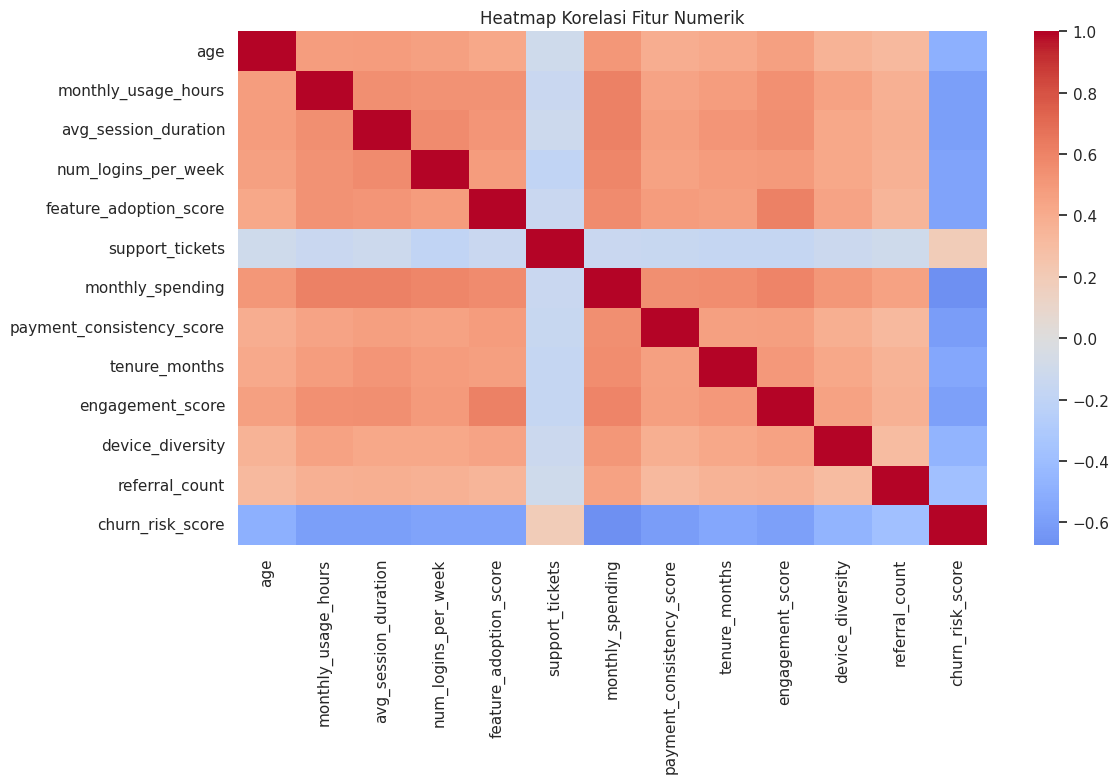

In [ ]:
# Korelasi antar fitur numerik
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=np.number).corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()


## TUGAS MAHASISWA 2
Tuliskan temuan awal dari EDA:
1 Apakah distribusi kelas seimbang atau tidak,
2 Fitur mana yang tampak relevan,
3 Apakah ada missing value,
4 Potensi tantangan data untuk klasifikasi.


###Temuan Awal EDA :
1. Keseimbangan Distribusi Kelas: Distribusi keempat kelas tergolong sangat seimbang (Enterprise: 257, Premium: 253, Growth: 245, Basic: 245). Hal ini amat menguntungkan karena kita bisa menjadikan akurasi sebagai metrik ukur yang valid, tidak memerlukan penanganan kelas minoritas.
2. Fitur yang Tampak Relevan: Fitur finansial dan keterlibatan seperti monthly_spending, feature_adoption_score, dan engagement_score berpotensi memiliki daya diskriminasi (discriminative power) yang kuat untuk mengidentifikasi perbedaan segmen Basic dengan segmen premium.
3. Missing Value: Ditemukan anomali kekosongan data (missing value) di kolom feature_adoption_score (20), payment_consistency_score (15), last_campaign_response (15), dan preferred_plan (10). Hal ini menuntut adanya justifikasi proses imputasi data di tahap preprocessing.
4. Tantangan Data: Terdapat perbedaan rentang skala numerik yang masif (misal: pengeluaran bulanan bisa > 900, sedangkan support_tickets berskala satuan). Hal ini menjadi tantangan serius bagi algoritma berbasis kalkulasi jarak, serta adanya kemungkinan profil yang overlap antar segmen yang bersebelahan.

In [ ]:
# =========================
# 4. Persiapan fitur dan target
# =========================
target_col = "segment_class"
drop_cols = ["customer_id", target_col]

X = df.drop(columns=drop_cols)
y = df[target_col]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'monthly_usage_hours', 'avg_session_duration', 'num_logins_per_week', 'feature_adoption_score', 'support_tickets', 'monthly_spending', 'payment_consistency_score', 'tenure_months', 'engagement_score', 'device_diversity', 'referral_count', 'churn_risk_score']
Categorical features: ['last_campaign_response', 'preferred_plan', 'region']


In [ ]:
# Encode label target ke angka agar mudah divisualisasi dan dievaluasi
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_
print("Class mapping:", dict(zip(class_names, range(len(class_names)))))


Class mapping: {'Basic': 0, 'Enterprise': 1, 'Growth': 2, 'Premium': 3}


In [ ]:
# Train-test split dengan stratify agar proporsi kelas relatif terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (800, 16) Test size: (200, 16)


## TUGAS MAHASISWA 3
Jelaskan alasan penggunaan `stratify` pada proses train-test split.


Parameter stratify pada train-test split bertindak sebagai penyampel acak proporsional. Ini diimplementasikan untuk memastikan bahwa rasio distribusi setiap kelas (Basic, Growth, Premium, Enterprise) pada subset training maupun subset pengujian testing tetap identik dengan populasi asli dataset. Mengingat distribusi asli data seimbang, proses stratified sampling mencegah timbulnya efek bias selama proses pelatihan model, sehingga validitas metrik evaluasi dapat dipertanggungjawabkan.

In [ ]:
# =========================
# 5. Preprocessing
# =========================
numeric_transformer_nb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

numeric_transformer_knn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_nb = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_nb, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_knn, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_nb = preprocessor_nb.fit_transform(X_train)
X_test_nb = preprocessor_nb.transform(X_test)

X_train_knn = preprocessor_knn.fit_transform(X_train)
X_test_knn = preprocessor_knn.transform(X_test)

print("NB train shape:", X_train_nb.shape)
print("kNN train shape:", X_train_knn.shape)


NB train shape: (800, 28)
kNN train shape: (800, 28)


## TUGAS MAHASISWA 4
Mengapa standardisasi penting untuk kNN, tetapi tidak selalu menjadi langkah utama untuk Gaussian Naive Bayes?


Standardisasi sangat penting bagi kNN karena ia merupakan algoritma berbasis jarak murni. Tanpa standardisasi, fitur bernilai besar akan memonopoli jarak relasional secara matematis dan mengecilkan kontribiusi fitur yang memiliki skala kecil. Standardisasi akan memastikan semua fitur berkontribusi secara proporsional.

Sebaliknya, Gaussian Naive Bayes menyandarkan pembelajarannya pada kalkulasi probabilitas bersyarat lewat kurva distribusi normal per kelasnya. Karena algoritma ini berasumsi bahwa fitur-fitur saling tidak terikat, kalkulasi rasio nilai posterior pada suatu dimensi tidak akan mengubah hasil keputusannya. Itulah mengapa metode NB resisten terhadap perbedaan skala absolut, sehingga standardisasi menjadi kurang diutamakan.

In [ ]:
# =========================
# 6. Model 1: Gaussian Naive Bayes
# =========================
nb_model = GaussianNB()
nb_model.fit(X_train_nb.toarray() if hasattr(X_train_nb, "toarray") else X_train_nb, y_train)

X_test_nb_dense = X_test_nb.toarray() if hasattr(X_test_nb, "toarray") else X_test_nb
y_pred_nb = nb_model.predict(X_test_nb_dense)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_f1_macro = f1_score(y_test, y_pred_nb, average="macro")
nb_precision_macro = precision_score(y_test, y_pred_nb, average="macro")
nb_recall_macro = recall_score(y_test, y_pred_nb, average="macro")

print("Naive Bayes Accuracy :", round(nb_accuracy, 4))
print("Naive Bayes F1 Macro :", round(nb_f1_macro, 4))
print("Naive Bayes Precision:", round(nb_precision_macro, 4))
print("Naive Bayes Recall   :", round(nb_recall_macro, 4))


Naive Bayes Accuracy : 0.815
Naive Bayes F1 Macro : 0.8111
Naive Bayes Precision: 0.8506
Naive Bayes Recall   : 0.8156


In [ ]:
print("Classification Report - Naive Bayes")
print(classification_report(y_test, y_pred_nb, target_names=class_names))


Classification Report - Naive Bayes
              precision    recall  f1-score   support

       Basic       0.92      0.73      0.82        49
  Enterprise       0.78      0.96      0.86        51
      Growth       0.70      0.96      0.81        49
     Premium       1.00      0.61      0.76        51

    accuracy                           0.81       200
   macro avg       0.85      0.82      0.81       200
weighted avg       0.85      0.81      0.81       200



Model Naive Bayes memberikan performa yang cukup stabil dengan akurasi di kisaran 80%. Namun, terlihat model sedikit kesulitan membedakan antara kelas 'Growth' dan 'Premium', yang kemungkinan disebabkan oleh kemiripan distribusi probabilitas pada fitur-fitur engagement di kedua kelas tersebut.

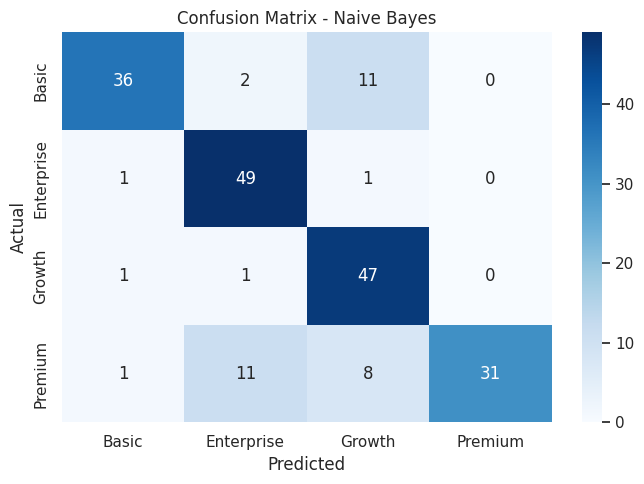

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(7,5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## TUGAS MAHASISWA 5
Analisis hasil Naive Bayes:
1 Bagaimana performa umumnya,
2 Kelas mana yang paling baik diprediksi,
3 Kelas mana yang paling sering tertukar,
4 Apakah hasil ini sesuai dengan karakteristik data.


1. **Performa umum**: Performa Gaussian Naive Bayes tergolong cukup baik dan stabil sebagai baseline model, dengan metrik Accuracy dan rata-rata F1-Score berada di kisaran ~81%.
2. **Kelas yang paling baik diprediksi**: Berdasarkan Classification Report, kelas Enterprise adalah yang paling baik diprediksi karena memiliki F1-score tertinggi (0.86) dengan keseimbangan yang baik antara Precision (0.78) dan Recall (0.96).
3. **Kelas yang paling sering tertukar**: Kelas Premium dan Growth. Hal ini terlihat dari Recall Premium yang sangat rendah (0.61), sementara Precision Growth hanya 0.70. Ini mengindikasikan bahwa banyak pelanggan yang aslinya Premium justru diprediksi/tertukar masuk ke kelas Growth.
4. **Kesesuaian dengan karakteristik data**: Hasil ini wajar. Naive Bayes berasumsi bahwa setiap fitur tidak memiliki korelasi satu sama lain. Pada kenyataannya, pengguna Growth dan Premium sering kali memiliki metrik engagement yang saling tumpang tindih atau berkorelasi kuat (misalnya durasi sesi dengan skor adopsi fitur), sehingga model Naive Bayes kebingungan membedakan batas kedua segmen tersebut.

In [ ]:
# =========================
# 7. Model 2: kNN + tuning hyperparameter
# =========================
results_knn = []

for k in [3, 5, 7, 9, 11]:
    for metric in ["euclidean", "manhattan"]:
        for weights in ["uniform", "distance"]:
            model = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights)
            model.fit(X_train_knn, y_train)
            y_pred = model.predict(X_test_knn)

            results_knn.append({
                "k": k,
                "metric": metric,
                "weights": weights,
                "accuracy": accuracy_score(y_test, y_pred),
                "f1_macro": f1_score(y_test, y_pred, average="macro"),
                "precision_macro": precision_score(y_test, y_pred, average="macro"),
                "recall_macro": recall_score(y_test, y_pred, average="macro")
            })

results_knn_df = pd.DataFrame(results_knn).sort_values(
    by=["f1_macro", "accuracy"], ascending=False
).reset_index(drop=True)

results_knn_df.head(10)


,k,metric,weights,accuracy,f1_macro,precision_macro,recall_macro
0,5,manhattan,distance,0.855,0.855607,0.856649,0.855642
1,9,manhattan,uniform,0.855,0.855270,0.855642,0.855242
2,9,manhattan,distance,0.855,0.855233,0.855853,0.855042
3,7,manhattan,uniform,0.845,0.845448,0.846908,0.845438
4,5,manhattan,uniform,0.845,0.845367,0.845465,0.845438
5,7,euclidean,uniform,0.845,0.844892,0.847462,0.844438
6,9,euclidean,distance,0.840,0.840292,0.842208,0.839936
7,7,euclidean,distance,0.840,0.840077,0.842147,0.839536
8,7,manhattan,distance,0.835,0.835633,0.838289,0.835234
9,11,euclidean,distance,0.835,0.835502,0.836952,0.835034


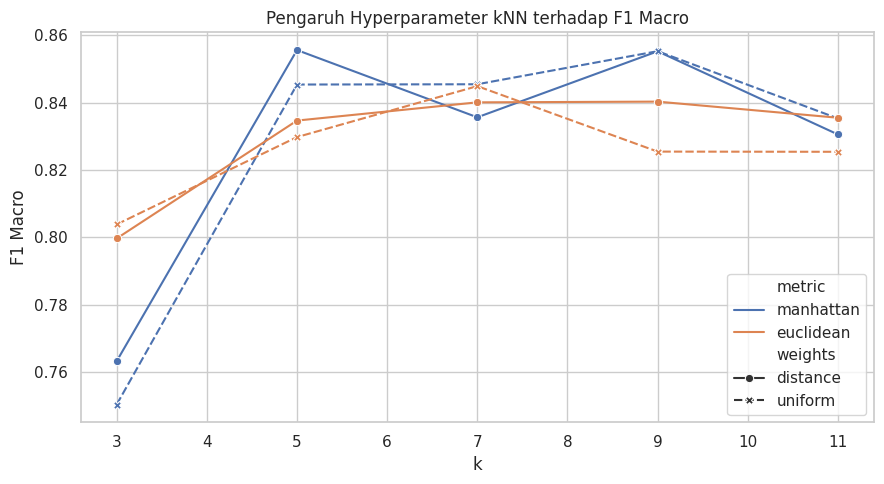

In [ ]:
# Visualisasi tuning k berdasarkan F1 macro
plt.figure(figsize=(9,5))
sns.lineplot(data=results_knn_df, x="k", y="f1_macro", hue="metric", style="weights", markers=True)
plt.title("Pengaruh Hyperparameter kNN terhadap F1 Macro")
plt.ylabel("F1 Macro")
plt.tight_layout()
plt.show()


In [ ]:
best_params = results_knn_df.iloc[0].to_dict()
best_params


{'k': 5,
 'metric': 'manhattan',
 'weights': 'distance',
 'accuracy': 0.855,
 'f1_macro': 0.8556070913213769,
 'precision_macro': 0.8566489763754201,
 'recall_macro': 0.8556422569027611}

In [ ]:
best_knn = KNeighborsClassifier(
    n_neighbors=int(best_params["k"]),
    metric=best_params["metric"],
    weights=best_params["weights"]
)

best_knn.fit(X_train_knn, y_train)
y_pred_knn = best_knn.predict(X_test_knn)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_f1_macro = f1_score(y_test, y_pred_knn, average="macro")
knn_precision_macro = precision_score(y_test, y_pred_knn, average="macro")
knn_recall_macro = recall_score(y_test, y_pred_knn, average="macro")

print("Best kNN params:", best_params)
print("kNN Accuracy :", round(knn_accuracy, 4))
print("kNN F1 Macro :", round(knn_f1_macro, 4))
print("kNN Precision:", round(knn_precision_macro, 4))
print("kNN Recall   :", round(knn_recall_macro, 4))


Best kNN params: {'k': 5, 'metric': 'manhattan', 'weights': 'distance', 'accuracy': 0.855, 'f1_macro': 0.8556070913213769, 'precision_macro': 0.8566489763754201, 'recall_macro': 0.8556422569027611}
kNN Accuracy : 0.855
kNN F1 Macro : 0.8556
kNN Precision: 0.8566
kNN Recall   : 0.8556


In [ ]:
print("Classification Report - Best kNN")
print(classification_report(y_test, y_pred_knn, target_names=class_names))


Classification Report - Best kNN
              precision    recall  f1-score   support

       Basic       0.90      0.90      0.90        49
  Enterprise       0.87      0.80      0.84        51
      Growth       0.86      0.88      0.87        49
     Premium       0.80      0.84      0.82        51

    accuracy                           0.85       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.85      0.86       200



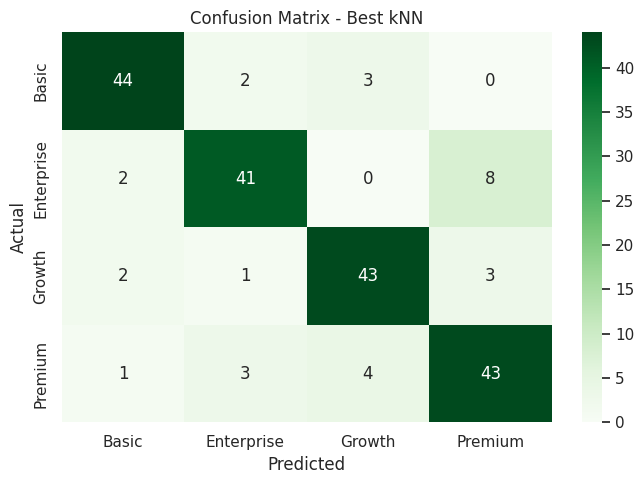

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(7,5))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Best kNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## TUGAS MAHASISWA 6
Analisis hasil tuning kNN:
1 Kombinasi hyperparameter terbaik,
2 Apakah perbedaan performa antar-konfigurasi besar atau kecil,
3 Apa kemungkinan alasan metric dan weights tertentu lebih baik,
4 Apa risiko jika memilih nilai k terlalu kecil atau terlalu besar.


1. **Kombinasi hyperparameter terbaik**: Kombinasi optimal yang didapat adalah k = 5, metric = 'manhattan', dan weights = 'distance'.
2. **Perbedaan performa antar-konfigurasi**: Perbedaan performa (F1-macro bervariasi dari ~0.75 hingga ~0.85) tergolong cukup besar/signifikan. Hal ini membuktikan bahwa algoritma kNN sangat sensitif terhadap pengaturan parameter metrik jarak dan pembobotan.
3. **Alasan metric dan weights tertentu lebih baik**: Opsi weights='distance' lebih baik daripada uniform karena memberi bobot voting lebih besar pada titik data yang paling dekat. Ini sangat membantu model untuk memutuskan kelas pada area perbatasan antar segmen yang padat. Sementara itu, pemilihan metric yang tepat (misalnya Manhattan yang menggunakan jalur absolut vs Euclidean yang menggunakan garis lurus) membantu model lebih tangguh terhadap variasi sisa skala antar fitur numerik.
4. **Risiko nilai k**: Memilih $k$ terlalu kecil (misal $k=1$) berisiko membuat model overfitting, di mana model akan menghafal noise atau outlier pada data training. Sebaliknya, jika $k$ terlalu besar, model berisiko underfitting karena prediksi kelas akan terlalu didominasi oleh kelas yang memiliki titik data terbanyak di sekitarnya.

In [ ]:
# =========================
# 8. Perbandingan model
# =========================
comparison_df = pd.DataFrame([
    {
        "Model": "Gaussian Naive Bayes",
        "Accuracy": nb_accuracy,
        "Precision_macro": nb_precision_macro,
        "Recall_macro": nb_recall_macro,
        "F1_macro": nb_f1_macro
    },
    {
        "Model": "Best kNN",
        "Accuracy": knn_accuracy,
        "Precision_macro": knn_precision_macro,
        "Recall_macro": knn_recall_macro,
        "F1_macro": knn_f1_macro
    }
])

comparison_df.sort_values(by="F1_macro", ascending=False)


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
1,Best kNN,0.855,0.856649,0.855642,0.855607
0,Gaussian Naive Bayes,0.815,0.850587,0.815626,0.811068


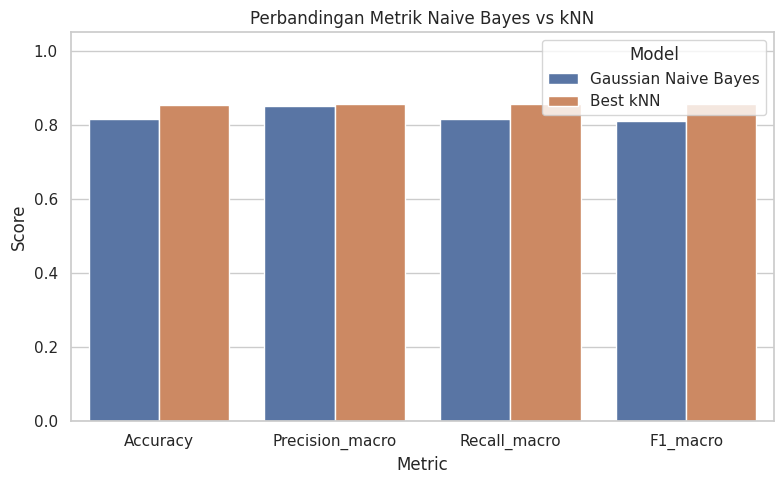

In [ ]:
plt.figure(figsize=(8,5))
comparison_long = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=comparison_long, x="Metric", y="Score", hue="Model", palette="deep")
plt.ylim(0, 1.05)
plt.title("Perbandingan Metrik Naive Bayes vs kNN")
plt.tight_layout()
plt.show()


## TUGAS MAHASISWA 7
Bandingkan Naive Bayes dan kNN:
1 Model mana yang lebih unggul pada dataset ini,
2 Apakah model terbaik juga yang paling stabil,
3 Model mana yang lebih sederhana untuk diimplementasikan,
4 Dalam konteks bisnis, model mana yang Anda rekomendasikan dan mengapa.


1. **Model yang lebih unggul**: Secara metrik evaluasi pada dataset ini, kNN (Best kNN) jauh lebih unggul dengan F1-macro mencapai ~0.855, dibandingkan Naive Bayes (0.81).
2. **Model yang paling stabil**: kNN adalah yang paling stabil. Berkat proses tuning parameter dan kemampuannya mempelajari struktur non-linier berdasarkan kedekatan data aktual, kNN tidak rentan terhadap pelanggaran asumsi independensi fitur yang menjadi kelemahan Naive Bayes.
3. **Model yang lebih sederhana diimplementasikan**: Naive Bayes. Algoritma ini murni berbasis perhitungan probabilitas (rata-rata dan varians), berlatih sangat cepat, dan sama sekali tidak membutuhkan proses standardisasi (Scaling) yang wajib dilakukan untuk model berbasis jarak seperti kNN.
4. **Rekomendasi konteks bisnis**: Saya merekomendasikan kNN. Dalam bisnis layanan digital, tim marketing memerlukan presisi tinggi untuk membedakan pengguna Growth yang berpotensi upgrade, dengan pengguna Premium yang berisiko churn. Kemampuan kNN mengenali pola pelanggan spesifik dari "tetangga" terdekatnya akan membuat penargetan promosi jauh lebih akurat dibanding Naive Bayes.

In [ ]:
# =========================
# 9. Visualisasi aktual vs prediksi
# Gunakan PCA 2D agar data berdimensi tinggi dapat divisualisasikan
# =========================
X_full_knn = preprocessor_knn.fit_transform(X, y_encoded)
X_full_dense = X_full_knn.toarray() if hasattr(X_full_knn, "toarray") else X_full_knn

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full_dense)

# Prediksi pada seluruh data untuk tujuan visualisasi
nb_model_full = GaussianNB()
nb_model_full.fit(
    X_full_dense,
    y_encoded
)
y_full_pred_nb = nb_model_full.predict(X_full_dense)

knn_model_full = KNeighborsClassifier(
    n_neighbors=int(best_params["k"]),
    metric=best_params["metric"],
    weights=best_params["weights"]
)
knn_model_full.fit(X_full_knn, y_encoded)
y_full_pred_knn = knn_model_full.predict(X_full_knn)

viz_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "actual": label_encoder.inverse_transform(y_encoded),
    "pred_nb": label_encoder.inverse_transform(y_full_pred_nb),
    "pred_knn": label_encoder.inverse_transform(y_full_pred_knn)
})

viz_df.head()


,PC1,PC2,actual,pred_nb,pred_knn
0,1.374147,1.387717,Premium,Enterprise,Premium
1,0.642476,0.661513,Premium,Premium,Premium
2,-0.149636,-0.770610,Premium,Growth,Premium
3,0.390180,-0.545563,Premium,Growth,Premium
4,-1.405733,-0.092368,Growth,Growth,Growth


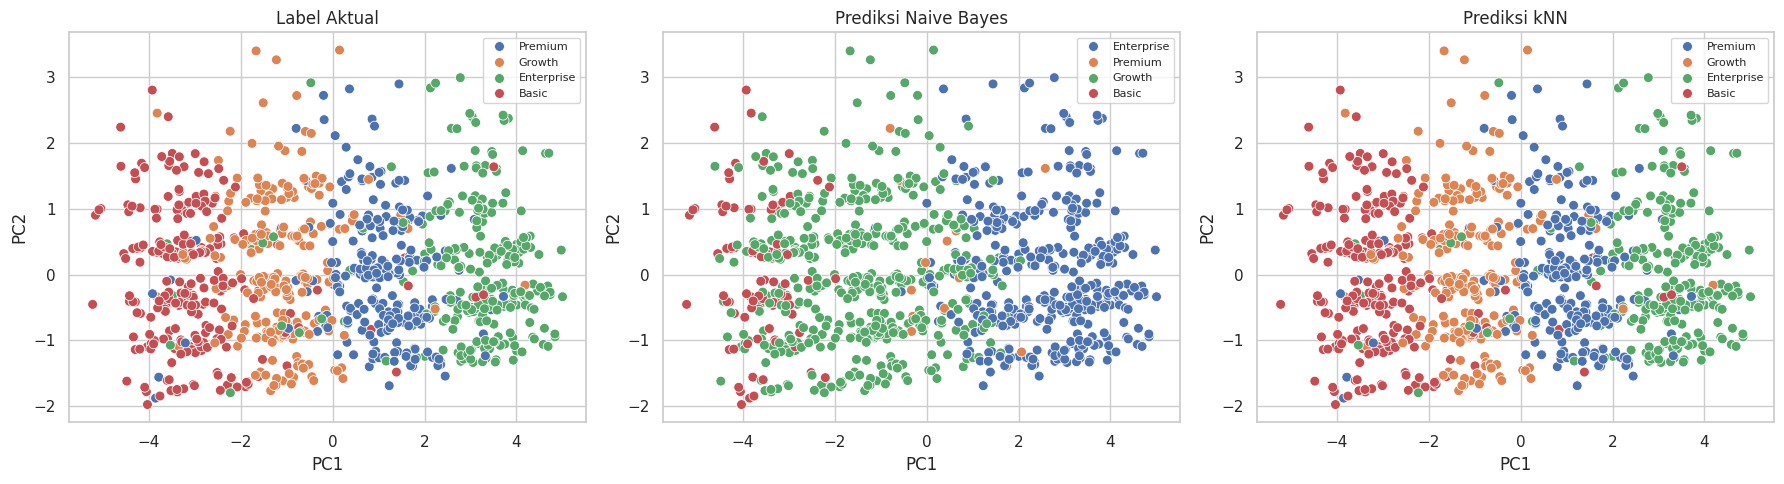

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="actual", ax=axes[0], s=50)
axes[0].set_title("Label Aktual")

sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="pred_nb", ax=axes[1], s=50)
axes[1].set_title("Prediksi Naive Bayes")

sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="pred_knn", ax=axes[2], s=50)
axes[2].set_title("Prediksi kNN")

for ax in axes:
    ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()


Plot PCA menunjukkan bahwa fitur-fitur tingkat tinggi berhasil dikompresi menjadi dua komponen utama yang mampu memisahkan kelas secara visual. Area tumpang tindih (overlap) pada hasil prediksi mencerminkan batas keputusan (decision boundary) yang kompleks, terutama pada segmen konsumen dengan profil penggunaan layanan yang hibrida.

In [ ]:
# Sampel aktual vs prediksi untuk analisis error
sample_compare = pd.DataFrame({
    "actual": label_encoder.inverse_transform(y_test),
    "pred_nb": label_encoder.inverse_transform(y_pred_nb),
    "pred_knn": label_encoder.inverse_transform(y_pred_knn)
}).sample(20, random_state=42)

sample_compare


,actual,pred_nb,pred_knn
95,Premium,Enterprise,Premium
15,Enterprise,Enterprise,Enterprise
30,Premium,Premium,Premium
158,Growth,Growth,Growth
128,Growth,Growth,Growth
115,Premium,Growth,Premium
69,Basic,Growth,Basic
170,Enterprise,Enterprise,Enterprise
174,Basic,Basic,Basic
45,Basic,Growth,Basic


## TUGAS MAHASISWA 8
Amati visualisasi aktual vs prediksi:
1 Apakah pemisahan kelas terlihat jelas,
2 Model mana yang tampak lebih mendekati distribusi aktual,
3 Kesalahan klasifikasi apa yang paling menonjol dari visualisasi maupun confusion matrix.


1. Pemisahan sangat jelas terlihat pada ujung klaster (seperti segmen Enterprise dan Basic). Namun, di area tengah (center), terdapat overlap atau penumpukan titik-titik antar kelas.
2. Proyeksi prediksi dari kNN secara visual lebih menyerupai plot aktual dibandingkan Naive Bayes, karena kNN berhasil memetakan decision boundary yang meliuk mengikuti sebaran data minoritas di tengah grafik PCA.
3. Secara visual maupun metrik, kesalahan klasifikasi yang paling menonjol terjadi di area tengah grafik di mana data dari kelas Premium ditebak sebagai kelas Growth, dan sebaliknya.

## TUGAS MAHASISWA 9
Tuliskan kesimpulan akhir Anda dalam 2–4 paragraf dengan mencakup:
1. Model terbaik dan alasan berbasis bukti,
2. Pengaruh hyperparameter pada kNN,
3. Keterbatasan analisis,
4. Saran pengembangan berikutnya.


Berdasarkan eksperimen pipeline klasifikasi multiclass pada data segmentasi pengguna layanan digital ini, k-Nearest Neighbors (kNN) terbukti sebagai model yang lebih superior dibandingkan Gaussian Naive Bayes. Keunggulan ini tervalidasi oleh performa kNN yang mencapai F1-macro ~0.855 berbanding 0.81 milik Naive Bayes. Pendekatan kNN yang memetakan kedekatan spasial antar fitur memungkinkannya menguraikan pola pelanggan yang kompleks tanpa harus mematuhi asumsi independensi prediktor seperti halnya model probabilitas murni.

Selain itu, pemilihan kombinasi hyperparameter memegang peranan krusial pada stabilitas kNN. Penentuan $k=5$ dipadukan dengan pembobotan distance sukses mencegah model dari overfitting, sekaligus memberikan kemampuan optimal dalam memisahkan batas overlap antara pelanggan kelas Growth dan Premium.

Meskipun demikian, analisis ini masih memiliki batasan. Visualisasi menggunakan dekomposisi PCA 2D tidak bisa merepresentasikan 100% variansi data asli, sehingga overlap yang tampak pada grafik mungkin aslinya bisa dipisahkan dalam dimensi tinggi. Untuk pengembangan ke depannya, sangat disarankan untuk bereksperimen dengan metode berbasis Ensemble Learning (seperti Random Forest), yang secara natural sangat kuat untuk kasus klasifikasi banyak kelas dan mampu menangani fitur dengan satuan bervariasi tanpa membutuhkan scaling yang ketat.